True Positive :  4
True Negative :  0
False Positive :  4
False Negative :  0
True Positive Rate :  1.0
False Positive Rate :  1.0
********************
True Positive :  2
True Negative :  4
False Positive :  0
False Negative :  2
True Positive Rate :  0.5
False Positive Rate :  0.0
********************
True Positive :  4
True Negative :  0
False Positive :  4
False Negative :  0
True Positive Rate :  1.0
False Positive Rate :  1.0
********************
The score of the model is : 1.0
FPR: [0. 0. 0. 1.] , TPR: [0.   0.25 1.   1.  ] , THRESHOLD: [       inf 0.63839327 0.59343379 0.54685225]


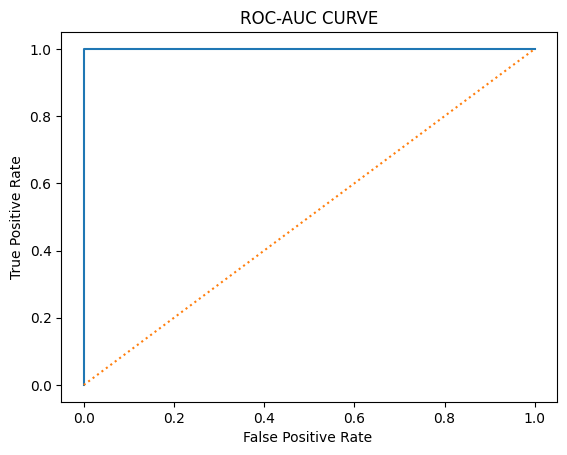

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix , roc_auc_score , roc_curve

# Independent Features
weights = np.array([30, 35, 40, 45, 60, 70, 80, 90]).reshape(-1,1)
# Dependent Feature or Target
obese = [0, 0, 0, 0, 1, 1, 1, 1]

# Data Modeling and Training
logistic_model = LogisticRegression(penalty='elasticnet' , solver='saga' , C=0.01 , l1_ratio=0.3)
logistic_model.fit(weights,obese)

# Model Predicted Probabilities : Only for Positive class , negative class probability = 1-positive.
model_predicted_probabilities = logistic_model.predict_proba(weights)[:,1]

# Defining Different Thresholds
Thresholds = [0.50 , 0.61 , 0.4]

def plot_confusionMatrix(threshold):
  prediction  = (model_predicted_probabilities >=threshold).astype('int')
  cm = confusion_matrix(obese , prediction)
  print('True Positive : ', cm[1][1])
  print('True Negative : ', cm[0][0])
  print('False Positive : ', cm[0][1])
  print('False Negative : ', cm[1][0])
  print('True Positive Rate : ', cm[1][1]/(cm[1][1]+cm[1][0]))
  print('False Positive Rate : ', cm[0][1]/(cm[0][1]+cm[0][0]))
  print('*'*20)

for threshold in Thresholds :
  plot_confusionMatrix(threshold)

# getting the score of the model .
score = roc_auc_score(obese , model_predicted_probabilities)
print(f'The score of the model is : {score}')
fpr,tpr,threshold = roc_curve(obese , model_predicted_probabilities)
print(f'FPR: {fpr} , TPR: {tpr} , THRESHOLD: {threshold}')

# plotting the roc curve
plt.title('ROC-AUC CURVE')
plt.plot(fpr , tpr)
plt.plot([0,1],[0,1], linestyle='dotted') # Random guess line
plt.xlabel('False Positive Rate ')
plt.ylabel('True Positive Rate')
plt.show()